- 사전 군집 수행
```
from sklearn.cluster import MiniBatchKmeans

k = 100
mbk = MiniBatchKmeans(
    n_clusters = k,
    batch_size = 1024,
    max_iter = 100,
    random_state = 3030
)
mbk.fit(np_arr_L2)

```

- actor를 여러개 선정하게 된다면, 각 actor에 대해 action들을 선정해야함

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/DCX analysis

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/DCX analysis


![image.png](attachment:image.png)

### 0. 군집데이터 불러오기

In [3]:
import pandas as pd

In [4]:
df = pd.read_pickle("./data/cluster_review.pkl")
df

,time,review,review_clean,tagged_review,vector,cluster
0,2023. 5. 30. 17:09,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,"[가계부, 지출, 생활비, 정산, 만, 원, 가계부, 인, 가구, 자취, 생활비, ...","[0.029383536, 0.016907085, 0.00081522897, -0.0...",0
1,2022. 10. 9. 22:41,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,"[신혼부부, 가계부, 신혼부부, 가계부, 화목, 화목, 신혼부부, 가계부, 입당, ...","[-0.01786139, -0.015472089, 0.03694084, -0.023...",0
2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,"[예금, 진실, 문득, 투자, 경제, 흐름, 알다, 예금, 안정, 이자, 바라보다,...","[0.022072772, 0.007191514, -0.02576847, -0.003...",0
3,2022. 7. 6. 5:19,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,"[카카오, 뱅크, 청년, 전세, 자금, 대출, 연장, 금리, 변동, 카카오, 뱅크,...","[0.092811614, 0.034037836, -0.06127037, -0.004...",0
4,2022. 8. 15. 18:08,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,"[탕, 다시다, 가다, 삼성, 병원, 가지, 베이컨, 그라탕, 해, 먹기, 미치다,...","[-0.04340123, -0.026072329, 0.018155538, -0.06...",1
...,...,...,...,...,...,...
1014,2022. 10. 11. 11:05,스물셋 으로 보는 월의 첫주 밸런스프렌즈 토글 리더스 나한테 많은 영감을 주는 쯔지...,스물셋 으로 보는 월의 첫주 밸런스프렌즈 토글 리더스 나한테 많은 영감을 주는 쯔지...,"[스물, 보다, 주, 밸런스, 프렌즈, 토글, 리더, 스, 많다, 영감, 주다, 쯔...","[0.0659607, 0.07645529, -0.043698166, -0.09170...",0
1015,2023. 2. 5. 22:20,직장인 갓생 탤이의 갓생 겨울방학 끝 동분서주 바쁜 탤이 공주놀이 넘 즐거워 모...,직장인 갓생 탤이의 갓생 겨울방학 끝 동분서주 바쁜 탤이 공주놀이 넘 즐거워 모...,"[직장인, 생, 탤이, 생, 겨울방학, 끝, 동분서주, 바쁘다, 탤, 공주, 넘다,...","[0.03549074, 0.027592776, 0.034498982, -0.0374...",0
1016,2023. 4. 3. 14:11,청년전세임대주택 청약 일정 신청 서울특별시 순위로 청약 신청 위치한국토지주택공사...,청년전세임대주택 청약 일정 신청 서울특별시 순위로 청약 신청 위치한국토지주택공사...,"[청년, 전세, 임대주택, 청약, 일정, 신청, 서울특별시, 순위, 청약, 신청, ...","[0.15022269, 0.042828105, -0.063947715, -0.001...",0
1017,2022. 9. 23. 1:20,외쳐 갓생 하이루이번 글 사진 레전드 많음 최대 장수 나의 갓생 시작 먹던 햄...,외쳐 갓생 하이루이번 글 사진 레전드 많음 최대 장수 나의 갓생 시작 먹던 햄...,"[외치다, 생, 하이루, 글, 사진, 레전드, 많다, 최대, 장수, 생, 시작, 먹...","[-0.10864438, -0.077697895, 0.12928155, -0.088...",1


### 1. LDA 이해하기
#### LDA(Latent Dirichlet Allocation)
- 토픽 모델링 : 문서의 집합으로부터 어떤 토픽이 존재하는지를 알아내기 위한 알고리즘
- LDA : 토픽 모델링의 대표적인 알고리즘
  - 주어진 문서에 대하여 각 문서에 어떤 주제들이 존재하는지에 대한 확률모형
  - 토픽별 단어의 분포, 문서별 토픽의 분포를 모두 추정
  - 실제 수십만개 이상의 문서가 있는 경우에는 직접 토픽을 찾아내는 것이 어렵기 때문에 LDA의 도움이 필요
  - LDA는 특정 토픽에 특정 단어가 나타날 확률을 추정
  - 노란색 토픽에는 gene이라는 단어가 등장할 확률이 0.04, dna는 0.02, genetic은 0.01이므로 노란색 토픽은 대략 유전자 관련 주제로 추정
    - 주어진 문서를 보면 파란색, 분홍색 토픽에 해당하는 단어보다는 노란색 토픽에 해당하는 단어들이 많으므로 문서의 메인 주제는 유전자 관련일 가능성이 큼

<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx07.png" width=50%>   
</center>


#### LDA 프로세스
[참고: WikiDocs - LDA 프로세스](https://wikidocs.net/30708)

1. 토픽 개수 k 설정
- 사용자가 LDA에 미리 토픽 개수(k)를 지정
2. 초기 토픽 할당
- 모든 문서의 각 단어에 대해, k개의 토픽 중 랜덤으로 하나를 할당
- 결과 : 각 문서는 여러 토픽에 속하며, 각 토픽은 단어 분포를 갖게 됨
3. 토픽 재할당 반복
- 목표 : 잘못 할당된 단어를 올바른 토픽으로 재분류하여, 문서와 토픽의 분포 개선
- 가정 : 문서 d의 단어 w는 현재 잘못된 토픽에 할당되어 있고, 나머지 단어들은 올바르게 할당되어 있다고 봄
- 재할당 기준 :
  - 문서 내 기준 : 문서 d내에서 토픽 t에 속한 단어들의 비율
  - 전체 문서 기준 : 전체 문서에서 토픽 t가 단어 w를 얼마나 잘 설명하는지(w의 분포)
  - 이 두 기준을 종합하여 각 단어 w의 토픽 할당을 반복적으로 재조정"

- 서로 연관되서 자주 뽑아지는 묶음을 토픽 > 해석은 우리가 붙여야함. (인공지능ㅇ은 비슷한 단어 그룹군끼리 묶어두는 역할 > 관련성있고 자주 등장하는)


### 2. LDA를 위한 데이터 전처리
- 단어토큰을 이용해서 단어사전 생성
- 각 문서별 단어의 등장 빈도 생성 (BOW)

In [5]:
# 군집 수 확인
print("0번 군집 : ",df[df['cluster']==0].shape)
print("0번 군집 : ",df[df['cluster']==1].shape)
print("0번 군집 : ",df[df['cluster']==2].shape)

0번 군집 :  (660, 6)
0번 군집 :  (310, 6)
0번 군집 :  (49, 6)


- actor분석 후, 그 군집이 유의미한 군집으로 분석을 수행해야함 >

In [6]:
# actor가 도출된 군집을 기준으로 ㅔ이터 필터링
df_cluster0 = df[df['cluster']==0]
df_cluster0.head()

,time,review,review_clean,tagged_review,vector,cluster
0,2023. 5. 30. 17:09,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,"[가계부, 지출, 생활비, 정산, 만, 원, 가계부, 인, 가구, 자취, 생활비, ...","[0.029383536, 0.016907085, 0.00081522897, -0.0...",0
1,2022. 10. 9. 22:41,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,"[신혼부부, 가계부, 신혼부부, 가계부, 화목, 화목, 신혼부부, 가계부, 입당, ...","[-0.01786139, -0.015472089, 0.03694084, -0.023...",0
2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,"[예금, 진실, 문득, 투자, 경제, 흐름, 알다, 예금, 안정, 이자, 바라보다,...","[0.022072772, 0.007191514, -0.02576847, -0.003...",0
3,2022. 7. 6. 5:19,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,"[카카오, 뱅크, 청년, 전세, 자금, 대출, 연장, 금리, 변동, 카카오, 뱅크,...","[0.092811614, 0.034037836, -0.06127037, -0.004...",0
5,2022. 9. 24. 15:01,직장인은 잠을 줄여야 한다 갓생살기 갓생살기 미라클 모닝시에 일어나 공복에 애플...,직장인은 잠을 줄여야 한다 갓생살기 갓생살기 미라클 모닝시에 일어나 공복에 애플...,"[직장인, 잠, 줄이다, 생, 살기, 생, 살기, 미라클, 모닝, 시, 일어나다, ...","[-0.02350657, -0.026915062, 0.09376785, -0.066...",0


#### 단어사전 생성 : 문서별 단어마다 고유한 ID 부여

In [7]:
!pip install new_value_analysis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.1 MB/s eta 0:00:00:00:0100:01


In [8]:
from gensim.corpora import Dictionary # 단어사전 구축용 도구

In [9]:
all_document = list(df_cluster0['tagged_review'])
all_document

[['가계부',
  '지출',
  '생활비',
  '정산',
  '만',
  '원',
  '가계부',
  '인',
  '가구',
  '자취',
  '생활비',
  '식비',
  '아끼다',
  '고정',
  '지출',
  '생활비',
  '아끼다',
  '무',
  '지출',
  '직장인',
  '짜다',
  '테크',
  '벌써',
  '가계부',
  '작성',
  '한지',
  '개월',
  '되어다',
  '생활비',
  '원',
  '생활비',
  '원',
  '생활비',
  '지난달',
  '대비',
  '원',
  '바',
  '가계부',
  '쓰다',
  '게',
  '의미',
  '없다',
  '정도',
  '로비',
  '슷',
  '개월',
  '사실',
  '달',
  '초',
  '저녁',
  '약속',
  '시험',
  '원서',
  '접수',
  '비',
  '고양이',
  '용품',
  '화끈하다',
  '돈',
  '써다',
  '버리다',
  '때문',
  '남다',
  '달',
  '쪼들리다',
  '사람',
  '이츠미',
  '달',
  '당근',
  '거래',
  '무려',
  '원',
  '벌다',
  '당근',
  '거래',
  '처음',
  '해보다',
  '떨리다',
  '애송이',
  '중고',
  '거래',
  '만렙',
  '되어다',
  '달',
  '갑작스럽다',
  '생기다',
  '약속',
  '서예',
  '비용',
  '벗어나다',
  '힐링',
  '수',
  '좋다',
  '지출',
  '보다',
  '고양이',
  '모래',
  '달',
  '만',
  '원',
  '들다',
  '줄',
  '모르다',
  '고양이',
  '간식',
  '밥',
  '장난감',
  '아니다',
  '모래',
  '제일',
  '비싸다',
  '달',
  '타투',
  '안',
  '전월',
  '덜',
  '써다',
  '거',
  '말',
  '후회',
  '전혀',
  '없다',
  '이제',
  '가계부'

In [10]:
word_dict = Dictionary(all_document)

In [11]:
print(word_dict)
print(word_dict.token2id)

Dictionary<13689 unique tokens: ['가계부', '가구', '간식', '갑작스럽다', '개월']...>
{'가계부': 0, '가구': 1, '간식': 2, '갑작스럽다': 3, '개월': 4, '거': 5, '거래': 6, '게': 7, '고양이': 8, '고정': 9, '공부': 10, '남다': 11, '달': 12, '답': 13, '당근': 14, '대비': 15, '덜': 16, '덜덜': 17, '돈': 18, '되어다': 19, '들다': 20, '때문': 21, '떨리다': 22, '로비': 23, '만': 24, '만렙': 25, '말': 26, '모래': 27, '모르다': 28, '목표': 29, '무': 30, '무려': 31, '물가': 32, '바': 33, '밥': 34, '버리다': 35, '벌다': 36, '벌써': 37, '벗어나다': 38, '보다': 39, '분석': 40, '비': 41, '비싸다': 42, '비용': 43, '사람': 44, '사실': 45, '생기다': 46, '생활비': 47, '서예': 48, '수': 49, '슷': 50, '시험': 51, '식비': 52, '써다': 53, '쓰다': 54, '아끼다': 55, '아니다': 56, '안': 57, '애송이': 58, '약': 59, '약속': 60, '없다': 61, '여름': 62, '열중': 63, '외식': 64, '용품': 65, '원': 66, '원서': 67, '의미': 68, '이제': 69, '이츠미': 70, '인': 71, '자취': 72, '작성': 73, '장난감': 74, '저녁': 75, '전월': 76, '전혀': 77, '접수': 78, '정도': 79, '정산': 80, '제외': 81, '제일': 82, '좋다': 83, '줄': 84, '줄이다': 85, '중고': 86, '지난달': 87, '지출': 88, '직장인': 89, '짜다': 90, '쪼들리다': 91, '처음': 92, '초'

#### 문서별로 단어등장 빈도 측정(BOW)

In [12]:
# 샘플 문장 변경
sample_txt = all_document[0]
print(sample_txt)
print(word_dict.doc2bow(all_document[0]))

['가계부', '지출', '생활비', '정산', '만', '원', '가계부', '인', '가구', '자취', '생활비', '식비', '아끼다', '고정', '지출', '생활비', '아끼다', '무', '지출', '직장인', '짜다', '테크', '벌써', '가계부', '작성', '한지', '개월', '되어다', '생활비', '원', '생활비', '원', '생활비', '지난달', '대비', '원', '바', '가계부', '쓰다', '게', '의미', '없다', '정도', '로비', '슷', '개월', '사실', '달', '초', '저녁', '약속', '시험', '원서', '접수', '비', '고양이', '용품', '화끈하다', '돈', '써다', '버리다', '때문', '남다', '달', '쪼들리다', '사람', '이츠미', '달', '당근', '거래', '무려', '원', '벌다', '당근', '거래', '처음', '해보다', '떨리다', '애송이', '중고', '거래', '만렙', '되어다', '달', '갑작스럽다', '생기다', '약속', '서예', '비용', '벗어나다', '힐링', '수', '좋다', '지출', '보다', '고양이', '모래', '달', '만', '원', '들다', '줄', '모르다', '고양이', '간식', '밥', '장난감', '아니다', '모래', '제일', '비싸다', '달', '타투', '안', '전월', '덜', '써다', '거', '말', '후회', '전혀', '없다', '이제', '가계부', '작성', '아니다', '분석', '외식', '식비', '공부', '고양이', '약', '약속', '줄이다', '답', '없다', '물가', '후', '덜덜', '여름', '휴가', '제외', '공부', '열중', '터', '생활비', '만', '원', '목표', '보다', '파이팅']
[(0, 5), (1, 1), (2, 1), (3, 1), (4, 2), (5, 1), (6, 3), (7, 1), (8, 4), (9, 1), (10

In [13]:
# 전체 문서에 적용
corpus = [word_dict.doc2bow(doc) for doc in all_document]

In [14]:
len(corpus)

660

### 3. LDA 모델 만들기

#### 3.1 LDA 테스트

In [15]:
import gensim

In [16]:
topic_num = 3 #생성할 토픽 수 설정(임의로 설정)

In [17]:
ldamodel = gensim.models.ldamodel.LdaModel(
    corpus, #각 문서를 단어 빈도수로 표현한 데이터
    id2word = word_dict, # 단어사전 연결 필요.
    num_topics = topic_num, #설정할 토픽 수
    passes = 10, # 전체 corpus를 대상으로 몇번 반복할지 설정
    iterations = 20, #각 문서별로 재할당하는 횟수 설정 > 과대적합 방지를 위해 적당한 값 설정 중요
    random_state = 42
)

In [18]:
ldamodel.print_topics(num_words = 20)

[(0,
  '0.009*"보다" + 0.009*"않다" + 0.009*"생각" + 0.008*"내" + 0.007*"없다" + 0.007*"돈" + 0.006*"수" + 0.006*"싶다" + 0.005*"좋다" + 0.005*"더" + 0.005*"들다" + 0.005*"자다" + 0.005*"쓰다" + 0.005*"가다" + 0.005*"지출" + 0.005*"아니다" + 0.004*"먹다" + 0.004*"그렇다" + 0.004*"받다" + 0.004*"가계부"'),
 (1,
  '0.009*"원" + 0.008*"만원" + 0.008*"수" + 0.007*"보다" + 0.007*"적금" + 0.006*"지출" + 0.006*"돈" + 0.006*"받다" + 0.005*"없다" + 0.005*"생각" + 0.005*"내" + 0.005*"통장" + 0.005*"모으다" + 0.004*"좋다" + 0.004*"쓰다" + 0.004*"않다" + 0.004*"들다" + 0.004*"가계부" + 0.004*"달" + 0.003*"되어다"'),
 (2,
  '0.015*"먹다" + 0.010*"보다" + 0.008*"원" + 0.008*"가다" + 0.006*"없다" + 0.006*"좋다" + 0.006*"내" + 0.006*"진짜" + 0.005*"거" + 0.005*"싶다" + 0.005*"아니다" + 0.005*"오다" + 0.004*"집" + 0.004*"안" + 0.004*"날" + 0.004*"들다" + 0.004*"자다" + 0.004*"맛있다" + 0.004*"수" + 0.004*"더"')]

In [19]:
# 특정문서에 할당된 토픽확인하기
corpus_topics = ldamodel.get_document_topics(corpus)

In [20]:
print(corpus_topics[200])

[(0, np.float32(0.9463995)), (1, np.float32(0.051896077))]


#### 3.2  topic 개수 선정

- LDA 모델의 성능을 평가하고 적절한 토픽 개수를 선정하기 위해 Perplexity(혼란도)와 Coherence(일관성) 지표를 활용

> 1. Perplexity(혼란도)  
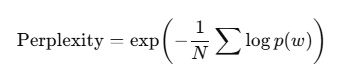
> - LDA 모델이 새로운 데이터에서 단어 또는 토픽의 분포를 얼마나 잘 예측하는지를 나타내는 평가지표
> 해석 :
>   - 낮은 값 : 모델이 데이터의 패턴을 잘 학습하여 예측력이 뛰어남
>   - 높은 값 : 모델의 예측력이 떨어짐
> - 주의사항 :
>   - 낮은 perplexity 값이 반드시 사람이 해석하기 좋은, 직관적인 토픽 구성을 보장하지는 않음
>   - 토픽 재할당 반복 횟수가 증가함에 따라 perplexity는 일반적으로 감소하지만, 특정 시점 이후에는 더 이상 감소하지 않거나 오히려 증가하는 현상이 발생할 수 있음(과적합)

> 2. Coherence(일관성)
> - 각 토픽 내에서 등장하는 단어들이 의미적으로 얼마나 연관되어 있는지를 측정하는 지표
> - 이는 사람이 해석하기에 얼마나 적합한 토픽인지 평가하기 위해서 제안됨(2010)
> - 해석 :
>   - 높은 값 : 토픽 내 단어들이 서로 의미적으로 연관이 깊어, 사람이 이해하기 쉬운 토픽임을 나타냄
>   - 낮은 값 : 토픽 내 단어들이 무작위로 나열되었거나, 관련성이 낮아 해석이 어렵다는 의미
> - 주의 사항 :
>   - 높은 Coherence 값이 반드시 모델이 최적의 일반화 성능을 가졌다는 의미는 아님
>   - 경우에 따라 너무 특정한 주제에 국한된 토픽이 만들어져, 과도하게 세부적이거나 제한된 정보를 제공할 위험이 있음
>   - 과적합의 가능성이 있으므로, Coherence 만으로 평가하기보다는 다른 지표(perplexity)와 함께 고려하는 것이 좋음

In [21]:
# perplexity 계산해보기
print("perplexity 점수 :" ,ldamodel.log_perplexity(corpus)) # -처리가 되지 않은

perplexity 점수 : -7.992552801626889


In [22]:
# 일반적인 perplexity 값으로 확인 -> -값 붙여준 후, exponential
import numpy as np
print("일반적인 perplexity 점수 : ",np.exp(-ldamodel.log_perplexity(corpus)))

일반적인 perplexity 점수 :  2958.8473966398656


In [23]:
# coherence 사용해보기
from gensim.models import CoherenceModel

In [24]:
coherence_model = CoherenceModel(
    model = ldamodel, #평가할 모델
    texts = all_document, #토픽간 단어 관련성을 측정
    dictionary = word_dict, #단어사전
    topn = 10 # 토픽별로 상;위10개 단어만 측정
)

In [25]:
print("coherence 점수 : ",coherence_model.get_coherence())

coherence 점수 :  0.3717001165993444


- 단어간의 연관성이 낮은편...

- topic수 별로 각 값을 확인하면서 몇개로 할지를 설정!
- perplexity는 안정성을 의미하기 때문에 크게 유의미하지 않
- coherence의 해석에 중점을 두고 파악하기

#### 3.3 토픽 수 별로 perplexity와 coherence 확인하기

In [26]:
from new_value_analysis.action_finder import lda_perplexity_coherence_plot

- 분석 진행 시 perplexit와 coherence 를 고려하여 해석
- perplexity는 낮을수록 조혹, coherence는 높을수록 좋다
- 여러 토픽 수 후보를 선정하고 하나씩 시각화하여 해석해보자!
- coherence가 상대적으로 중요하다

  0%|          | 0/8 [00:00<?, ?it/s]

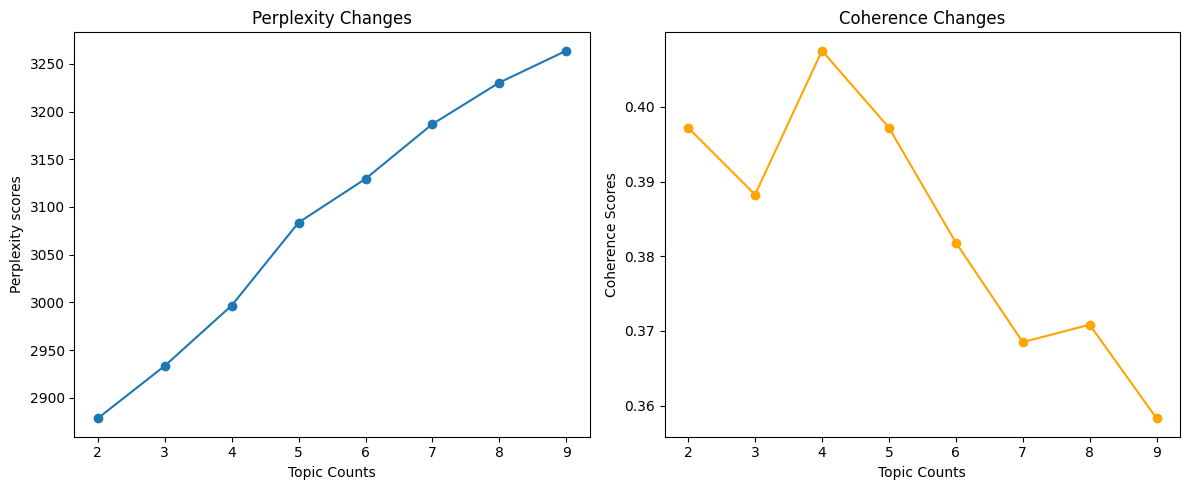

In [27]:
lda_perplexity_coherence_plot(
    corpus = corpus, #BOW 형태로 되어있는 말뭉치데이터
    word_dict = word_dict, #단어사전 넣기
    passes = 10, #전체 말뭉치 반복 횟수
    iterations = 20 , # 문서별 재할당 계산 횟수
    ## lda모델에 대한 기본 파라미터
    topic_range = range(2,10), # 토픽 개수 설정
    random_state = 2026,
    all_documents = all_document, #문서 리스트
    fixed_topn = 10 #상위단어 제한
)

- 4개 가 가장높고,5개/2개 토픽으로 활용하면 될듯?

- 토픽 수가 너무 낮으면 해석하기에 어려움..


#### 3.4 선정한 토픽 개수로 학습 후 action 넘버 매칭

In [28]:
topic_num = 4 #생성할 토픽 수 설정(임의로 설정)

In [29]:
ldamodel = gensim.models.ldamodel.LdaModel(
    corpus, #각 문서를 단어 빈도수로 표현한 데이터
    id2word = word_dict, # 단어사전 연결 필요.
    num_topics = topic_num, #설정할 토픽 수
    passes = 10, # 전체 corpus를 대상으로 몇번 반복할지 설정
    iterations = 20, #각 문서별로 재할당하는 횟수 설정 > 과대적합 방지를 위해 적당한 값 설정 중요
    random_state = 42
)

In [33]:
from new_value_analysis.action_finder import assign_action_number

In [34]:
action_number_assignment = assign_action_number(
    ldamodel, # 학습한 lda모델
    corpus = corpus
)

In [30]:
ldamodel.print_topics(num_words = 20)

[(0,
  '0.010*"보다" + 0.010*"생각" + 0.009*"않다" + 0.009*"내" + 0.008*"돈" + 0.007*"없다" + 0.007*"수" + 0.006*"싶다" + 0.006*"좋다" + 0.006*"들다" + 0.005*"더" + 0.005*"자다" + 0.005*"아니다" + 0.005*"가다" + 0.005*"쓰다" + 0.005*"그렇다" + 0.004*"받다" + 0.004*"시작" + 0.004*"오다" + 0.004*"해보다"'),
 (1,
  '0.009*"적금" + 0.008*"만원" + 0.008*"수" + 0.007*"받다" + 0.007*"보다" + 0.007*"원" + 0.006*"돈" + 0.006*"통장" + 0.006*"없다" + 0.005*"모으다" + 0.005*"좋다" + 0.005*"내" + 0.005*"생각" + 0.004*"않다" + 0.004*"들다" + 0.004*"사용" + 0.003*"쓰다" + 0.003*"뱅크" + 0.003*"카카오" + 0.003*"정도"'),
 (2,
  '0.015*"먹다" + 0.010*"보다" + 0.008*"원" + 0.008*"가다" + 0.007*"없다" + 0.006*"좋다" + 0.006*"진짜" + 0.006*"내" + 0.005*"거" + 0.005*"아니다" + 0.005*"안" + 0.005*"들다" + 0.005*"오다" + 0.005*"싶다" + 0.004*"날" + 0.004*"자다" + 0.004*"집" + 0.004*"수" + 0.004*"사람" + 0.004*"더"'),
 (3,
  '0.016*"지출" + 0.011*"원" + 0.010*"가계부" + 0.009*"소비" + 0.008*"보다" + 0.007*"먹다" + 0.007*"만원" + 0.006*"수" + 0.005*"생각" + 0.005*"쓰다" + 0.005*"없다" + 0.005*"않다" + 0.005*"돈" + 0.004*"달" + 0.004*"가다" + 0.0

In [35]:
action_number_assignment

[3,
 2,
 1,
 0,
 3,
 0,
 2,
 1,
 1,
 3,
 2,
 0,
 0,
 0,
 3,
 0,
 1,
 2,
 2,
 3,
 0,
 2,
 3,
 2,
 2,
 2,
 1,
 1,
 2,
 3,
 0,
 1,
 0,
 1,
 0,
 2,
 0,
 2,
 1,
 2,
 1,
 2,
 1,
 2,
 2,
 1,
 3,
 0,
 2,
 3,
 0,
 2,
 1,
 1,
 2,
 2,
 1,
 0,
 1,
 1,
 1,
 3,
 0,
 1,
 1,
 0,
 3,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 2,
 0,
 0,
 3,
 2,
 0,
 0,
 2,
 1,
 2,
 0,
 0,
 0,
 1,
 1,
 2,
 0,
 0,
 2,
 0,
 0,
 3,
 3,
 0,
 2,
 1,
 0,
 2,
 1,
 0,
 3,
 2,
 0,
 3,
 2,
 1,
 0,
 2,
 0,
 2,
 0,
 2,
 3,
 0,
 0,
 0,
 2,
 1,
 3,
 3,
 3,
 1,
 2,
 3,
 0,
 1,
 2,
 3,
 2,
 2,
 2,
 2,
 0,
 2,
 0,
 3,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 2,
 0,
 2,
 3,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 2,
 1,
 3,
 1,
 2,
 1,
 2,
 2,
 0,
 2,
 1,
 3,
 0,
 1,
 0,
 0,
 3,
 0,
 2,
 2,
 0,
 1,
 1,
 3,
 0,
 0,
 3,
 3,
 3,
 3,
 0,
 0,
 0,
 1,
 3,
 0,
 1,
 3,
 3,
 3,
 1,
 0,
 1,
 0,
 0,
 2,
 3,
 0,
 0,
 0,
 2,
 1,
 0,
 0,
 3,
 3,
 3,
 0,
 3,
 0,
 2,
 0,
 3,
 3,
 1,
 1,
 1,
 0,
 0,
 2,
 3,
 0,
 2,
 3,
 1,
 0,
 2,
 1,
 0,
 3,
 1,
 3,
 0,
 3,
 3,
 3,
 0,
 0,
 1,


In [37]:
!pwd

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/DCX analysis


In [38]:
# 액션넘버를 새로운 컬럼으로 지정하고 파일로 저장
df_cluster0['action_cluster'] = action_number_assignment
df_cluster0.to_pickle("./data/actor0_action.pkl")

/tmp/ipykernel_1223/2715571047.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster0['action_cluster'] = action_number_assignment


In [39]:
df_cluster0.head()

,time,review,review_clean,tagged_review,vector,cluster,action_cluster
0,2023. 5. 30. 17:09,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,"[가계부, 지출, 생활비, 정산, 만, 원, 가계부, 인, 가구, 자취, 생활비, ...","[0.029383536, 0.016907085, 0.00081522897, -0.0...",0,3
1,2022. 10. 9. 22:41,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,"[신혼부부, 가계부, 신혼부부, 가계부, 화목, 화목, 신혼부부, 가계부, 입당, ...","[-0.01786139, -0.015472089, 0.03694084, -0.023...",0,2
2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,"[예금, 진실, 문득, 투자, 경제, 흐름, 알다, 예금, 안정, 이자, 바라보다,...","[0.022072772, 0.007191514, -0.02576847, -0.003...",0,1
3,2022. 7. 6. 5:19,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,"[카카오, 뱅크, 청년, 전세, 자금, 대출, 연장, 금리, 변동, 카카오, 뱅크,...","[0.092811614, 0.034037836, -0.06127037, -0.004...",0,0
5,2022. 9. 24. 15:01,직장인은 잠을 줄여야 한다 갓생살기 갓생살기 미라클 모닝시에 일어나 공복에 애플...,직장인은 잠을 줄여야 한다 갓생살기 갓생살기 미라클 모닝시에 일어나 공복에 애플...,"[직장인, 잠, 줄이다, 생, 살기, 생, 살기, 미라클, 모닝, 시, 일어나다, ...","[-0.02350657, -0.026915062, 0.09376785, -0.066...",0,3


- 우리한테 필요한 의견들 위주로 모을 필요가 있다. (전처리, 클렌징 중요!!!ㅋ)

### 4. LDA 토픽모델링 시각화

#### 4.1 액션 비율 확인하기

In [41]:
df_cluster0['action_cluster'].value_counts()

,count
action_cluster,
0,242
2,176
1,122
3,120


#### 4.2 pyLDAvis 활용하기

- 왼쪽 : 각 토픽들의 거리와 크기를 비교하면서 분석
    - 토픽별 거리가 넓다면 사용되는 단어 그룹이 많이 차이난다
    - 토픽별 거리가 가깝다면 사용되는 단어 그룹이 비슷하다
- 오른쪽 : 전체 말뭉치에서 단어의 등장 빈도와 특정 토픽에서 특별하게 등장하는 단어의 중요성을 확인

- 람다 (0~1 조절) : 전체 말뭉치의 등장빈도와 특정 토픽 중요도의 가중치를 조절하는 파라미터
- 람다가 1에 가까울 수록 전체 말뭉치의 등장빈도 비중을 높인다.
- 람다가 0에 가까울수록 특정토픽에 등장하는 단어의 비중을 높인다
- 보통 논문에서는 0.5~0.6을 추천 (전체 단어등장 비율과 특정토픽의 중요성을 반정도 섞는게 이상적이라고 보기때문)

In [49]:
!pip install pyldavis

In [50]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis # pyLDAvis와 gensim LDA모델을 연결하는 패키지

In [46]:
# 시각화하기 위한 데이터형태로 변경
prepared_data = gensimvis.prepare(
    ldamodel, # 학습한 lda모델
    corpus, # 각 문서를 BOW로 변경한 데이터
    word_dict, # 단어사전
    
)

In [47]:
pyLDAvis.display(prepared_data)

- 해석할 때 살펴볼 도구!!

In [48]:
# HTML 파일로 저장하기
pyLDAvis.save_html(
    prepared_data, # 준비한 데이터 넣기
    "./ldavis_actor0_action.html" # 저장할 파일경로 및 파일명 설정
)

- 1. 토픽의 양을 확인 -> 원의 크기가 큼
- 2. 토픽간의 거리 -> 각 토픽들에 사용하는 단어 그룹군이 차이가 난다. 토픽수를 높게 설정하면 > 토픽들이 겹쳐서 나옴 (서로 사용하는 단어 그룹군이 겹친다)
- 해석법
    - 토픽 하나 선택. > 


    
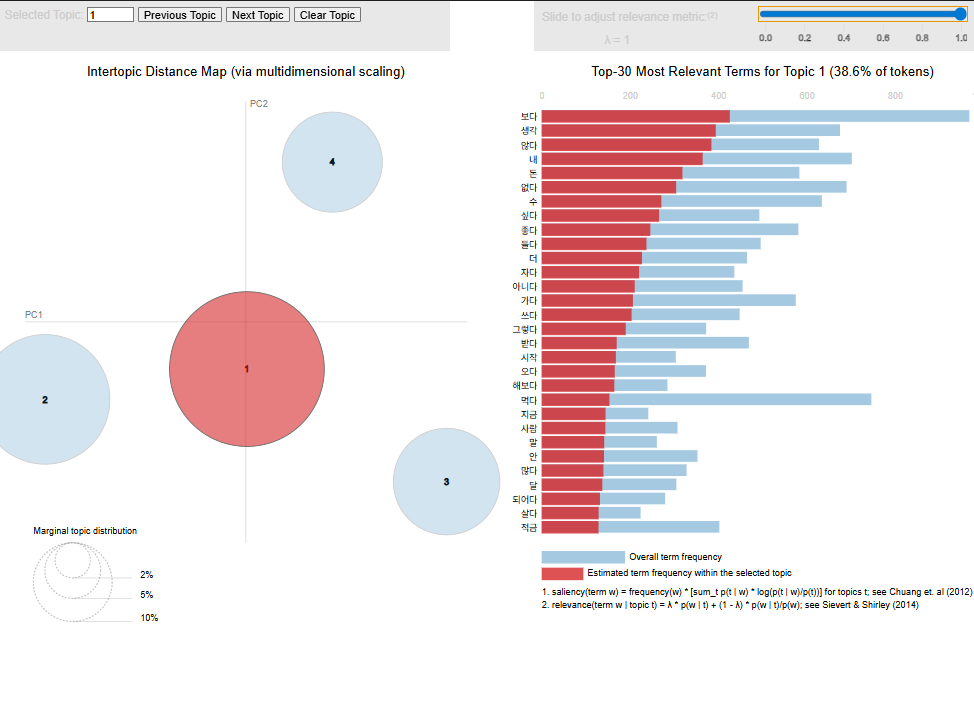

lambda 값은 가중치 비율
- 1에 가까울 수록 전체 말뭉치에서 등장빈도 위주
-0 : 현재 토픽에서 등장하는 가중치 값이 올라가도록 

- 권장하는 람다값 0.5~0.6 
- 람다를 너무 낮춰서 보면 해당 토픽에서만 해석할 가능성이 높음
- 람다를 너무 높이면 전체적인 말뭉치에서 등장하는 빈도를 확인


- 데이터의 퀄리티가 좋지 않으면 람다를 낮춰서 토픽에서 단어가 유의미하도록 해석하는 방법

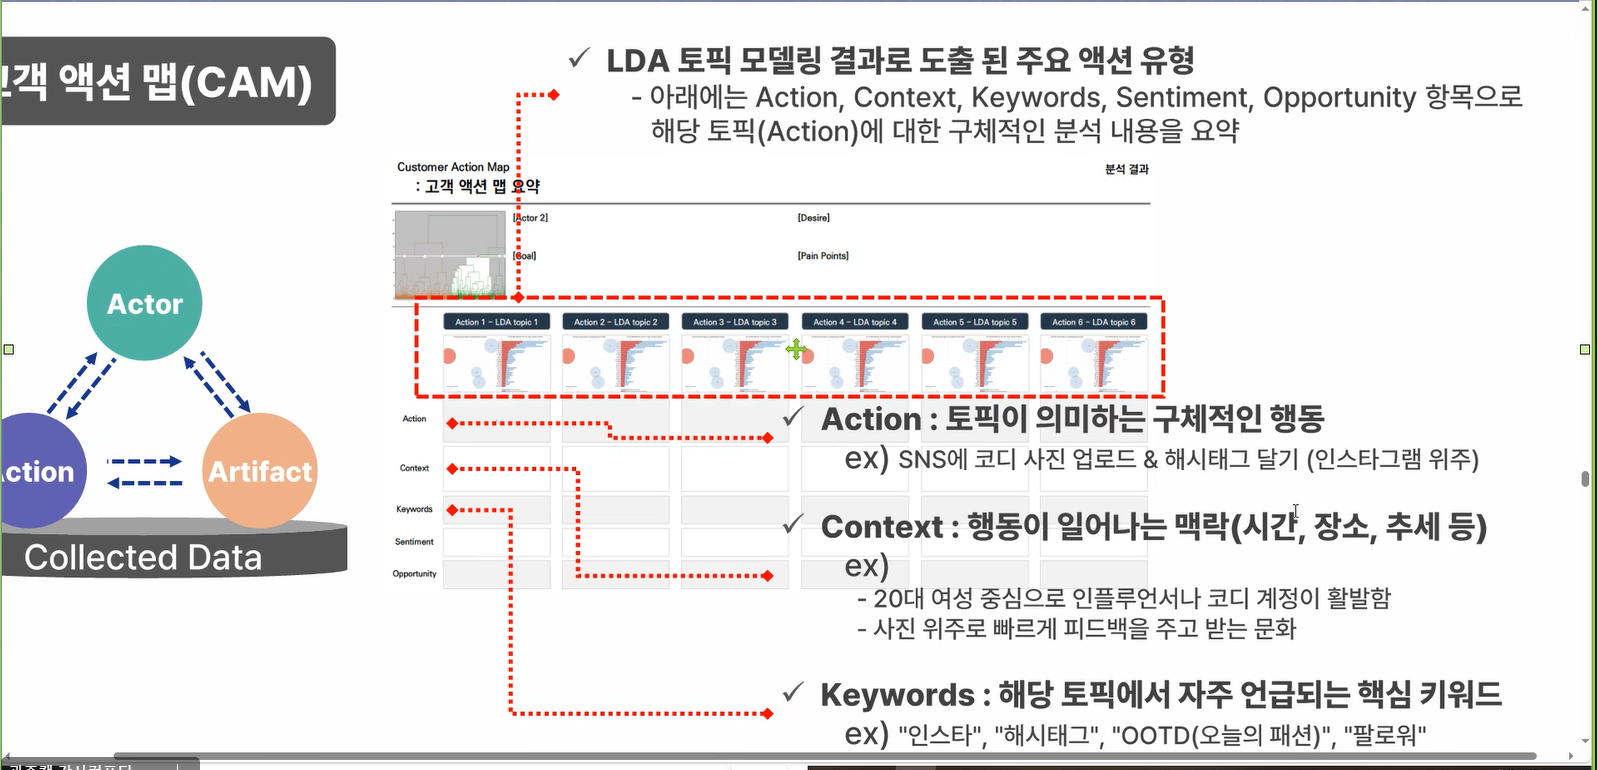

- 액션은 토픽과 연결해서 원문 을 같이 보면서 작성해야함

- Sentiment / Opportunity 는 다음주에ㅔ.... 

- action_cluster는 lda모델에서 붙인값과 pyLDAvis 붙인 클러스터 넘버링이 다름!

### 5. LDA 분석을 위한 작업
- LDA 모델의 토픽 index 번호와 pyLDAvis 토픽 index번호가 불일치 > 별도의 모델
- 해석의 편의성을 위해 pyLDAvis 기준으로 action 번호 수정

In [53]:
#LDA 모델의 topic 번호 확인
ldamodel.print_topics(num_words = 10)

[(0,
  '0.010*"보다" + 0.010*"생각" + 0.009*"않다" + 0.009*"내" + 0.008*"돈" + 0.007*"없다" + 0.007*"수" + 0.006*"싶다" + 0.006*"좋다" + 0.006*"들다"'),
 (1,
  '0.009*"적금" + 0.008*"만원" + 0.008*"수" + 0.007*"받다" + 0.007*"보다" + 0.007*"원" + 0.006*"돈" + 0.006*"통장" + 0.006*"없다" + 0.005*"모으다"'),
 (2,
  '0.015*"먹다" + 0.010*"보다" + 0.008*"원" + 0.008*"가다" + 0.007*"없다" + 0.006*"좋다" + 0.006*"진짜" + 0.006*"내" + 0.005*"거" + 0.005*"아니다"'),
 (3,
  '0.016*"지출" + 0.011*"원" + 0.010*"가계부" + 0.009*"소비" + 0.008*"보다" + 0.007*"먹다" + 0.007*"만원" + 0.006*"수" + 0.005*"생각" + 0.005*"쓰다"')]

- lambda 값을 최대로 하고 확인해야함

In [ ]:
# LDA - pyLDAvis 
# 0   - 1
# 1   - 3   
# 2   - 2
# 3   - 4

new_action_topic = []  # 새로운 토픽번호로 매핑된 리스트
for i in df_cluster0['action_cluster']: # 기존 action번호를 반복처리
    if i == 0 :
        new_action_topic.append(1)
    elif i == 1:
        new_action_topic.append(3)
    elif i == 2:
        new_action_topic.append(2)
    elif i == 3:
        new_action_topic.append(4)

In [56]:
# pyLDAvis 기준으로 업데이트
df_cluster0['action_cluster'] = new_action_topic
# 파일저장
df_cluster0.to_pickle("./data/actor_0_action.pkl")

/tmp/ipykernel_1223/2981334586.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster0['action_cluster'] = new_action_topic


In [59]:
# 필터링
topic3 = df_cluster0.loc[df_cluster0['action_cluster']==3,'review']

In [63]:
topic3.loc[topic3.str.contains("예금")]

,review
2,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...
9,월 편의점 짱구스트랩 새마을금고 예금 어제 미뤘던 할 일은행가기를 했다최근에 적금도...
39,아끼고모으고불리고 그리고 취업 후 처음으로 적금 만기 드디어 적금 만기나 취업하고...
55,는 일주일에 한번만 쓰나요 몰라요란 자고로 의식의 흐름 아니겄어요퇴근길에 쓰는...
76,금융 대 직장인 재테크 차곡 돈 모으기 매달 저축를 작성하기로 했다일단 나는 매일 ...
94,저축하는 아침부터 몸이 좋지가 않다 요새 면역력이 확 떨어지고 나서 자주 아...
251,하늘이 무너져도 솟아날 구멍은 있다 일동안 금주해야지 다짐했던 부분이 일만에 막을...
280,티끌 모아 태산 파킹통장 만들기 파킹통장 완전정복 꿈꾸는 주식은 엉망이고 유...
286,조카 수호의 첫 투자 이제 중이 되었으니 애플 매수말고지난 한 달정도 파생상품과 ...
358,회차갓생사는 아띠 자연 운동 재테크 무지개를 보다 점심 먹으러 식당 가다가...
